# Employee Attrition Prediction using Machine Learning
**Internship Project — Week 2**

This notebook builds a machine learning system to predict whether an employee is likely to leave the company, based on the IBM HR Analytics Employee Attrition dataset (1,470 employees, 35 columns).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
import warnings
warnings.filterwarnings('ignore')


## Task 1 — Data Loading & Exploration

In [2]:
df = pd.read_csv('HR_Attrition.csv')
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
rows, cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 1470, Columns: 35


In [4]:
print("Target column: Attrition (Yes/No)")
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / len(df)) * 100
print(attrition_counts)
print(f"\nAttrition rate: {attrition_rate:.2f}%")

Target column: Attrition (Yes/No)
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.12%


In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

Numeric columns (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


**Observation (Task 1):** Only 237 of 1,470 employees (16.12%) left the company, while 1,233 (83.88%) stayed. This is a **heavily imbalanced target** — a model that simply predicted "No" for everyone would already be 84% "accurate" while being completely useless for HR. This means accuracy alone is the wrong metric here; we need to rely on precision, recall, F1-score, and ROC-AUC instead, and we need to correct for the imbalance during model training (handled in Task 4 with `class_weight='balanced'`).

## Task 2 — Data Cleaning & Preprocessing

In [6]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found in the dataset.")

Missing values per column:
No missing values found in the dataset.


In [7]:
# Drop columns that add no predictive value (constant or pure identifiers)
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
print("Unique values check before dropping:")
for c in cols_to_drop:
    print(c, '->', df[c].nunique(), 'unique value(s)')

df = df.drop(columns=cols_to_drop)
print("\nShape after dropping:", df.shape)

Unique values check before dropping:
EmployeeNumber -> 1470 unique value(s)
Over18 -> 1 unique value(s)
StandardHours -> 1 unique value(s)
EmployeeCount -> 1 unique value(s)

Shape after dropping: (1470, 31)


In [8]:
# Convert target column to binary
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [9]:
# One-Hot Encode remaining categorical columns
cat_remaining = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_remaining)

df_encoded = pd.get_dummies(df, columns=cat_remaining, drop_first=True)
print("Shape after one-hot encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after one-hot encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [10]:
# Split features/target, then train/test split BEFORE scaling to avoid data leakage
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale only the original numeric features using StandardScaler
numeric_features = df.select_dtypes(include=np.number).drop(columns=['Attrition']).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Training set:", X_train_scaled.shape, " Test set:", X_test_scaled.shape)

Training set: (1176, 44)  Test set: (294, 44)


## Task 3 — Exploratory Data Analysis (EDA)

In [11]:
dept_attrition = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False) * 100
print("Attrition rate by Department (%):")
print(dept_attrition.round(2))

Attrition rate by Department (%):
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


In [12]:
role_attrition = df.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False) * 100
print("Attrition rate by Job Role (%):")
print(role_attrition.round(2))

Attrition rate by Job Role (%):
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


In [13]:
income_by_attrition = df.groupby('Attrition')['MonthlyIncome'].mean()
print("Average Monthly Income:")
print(f"  Employees who stayed: {income_by_attrition[0]:.0f}")
print(f"  Employees who left:   {income_by_attrition[1]:.0f}")
print(f"  Difference: {income_by_attrition[0] - income_by_attrition[1]:.0f} ({(1 - income_by_attrition[1]/income_by_attrition[0])*100:.1f}% lower for leavers)")

Average Monthly Income:
  Employees who stayed: 6833
  Employees who left:   4787
  Difference: 2046 (29.9% lower for leavers)


In [14]:
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].mean() * 100
print("Attrition rate by Work-Life Balance rating (1=Bad, 4=Best):")
print(wlb_attrition.round(2))

Attrition rate by Work-Life Balance rating (1=Bad, 4=Best):
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


In [15]:
tenure_attrition = df.groupby('YearsAtCompany')['Attrition'].mean() * 100
print("Attrition rate by Years at Company (first 10 tenure years):")
print(tenure_attrition.head(10).round(2))

Attrition rate by Years at Company (first 10 tenure years):
YearsAtCompany
0    36.36
1    34.50
2    21.26
3    15.62
4    17.27
5    10.71
6    11.84
7    12.22
8    11.25
9     9.76
Name: Attrition, dtype: float64


### Business Insights from EDA

1. **Sales loses employees fastest.** The Sales department has the highest attrition rate at 20.63%, followed by HR at 19.05%, while R&D is the most stable at 13.84%.
2. **Sales Representatives are the single highest-risk role.** Nearly 4 in 10 Sales Representatives leave (39.76% attrition) — more than double any other role except Lab Technicians (23.94%).
3. **Pay is a real factor, but not the whole story.** Employees who left earned an average of ₹4,787/month versus ₹6,833/month for those who stayed — a 30% gap — but pay alone won't explain attrition fully (see Task 4/5 feature importance).
4. **Poor work-life balance roughly doubles attrition risk.** Employees rating their work-life balance as "1 — Bad" leave at 31.25%, almost double the rate of employees rating it 3 or 4 (14–18%).
5. **New employees are the flight risk.** Attrition is highest in the first two years (36.4% in year 0, 34.5% in year 1) and drops sharply after year 2 (21.3%) and beyond (mostly single digits by year 5+) — meaning onboarding and the first 24 months are the critical retention window.


### Supporting Charts (Department/Role attrition and Income comparison)

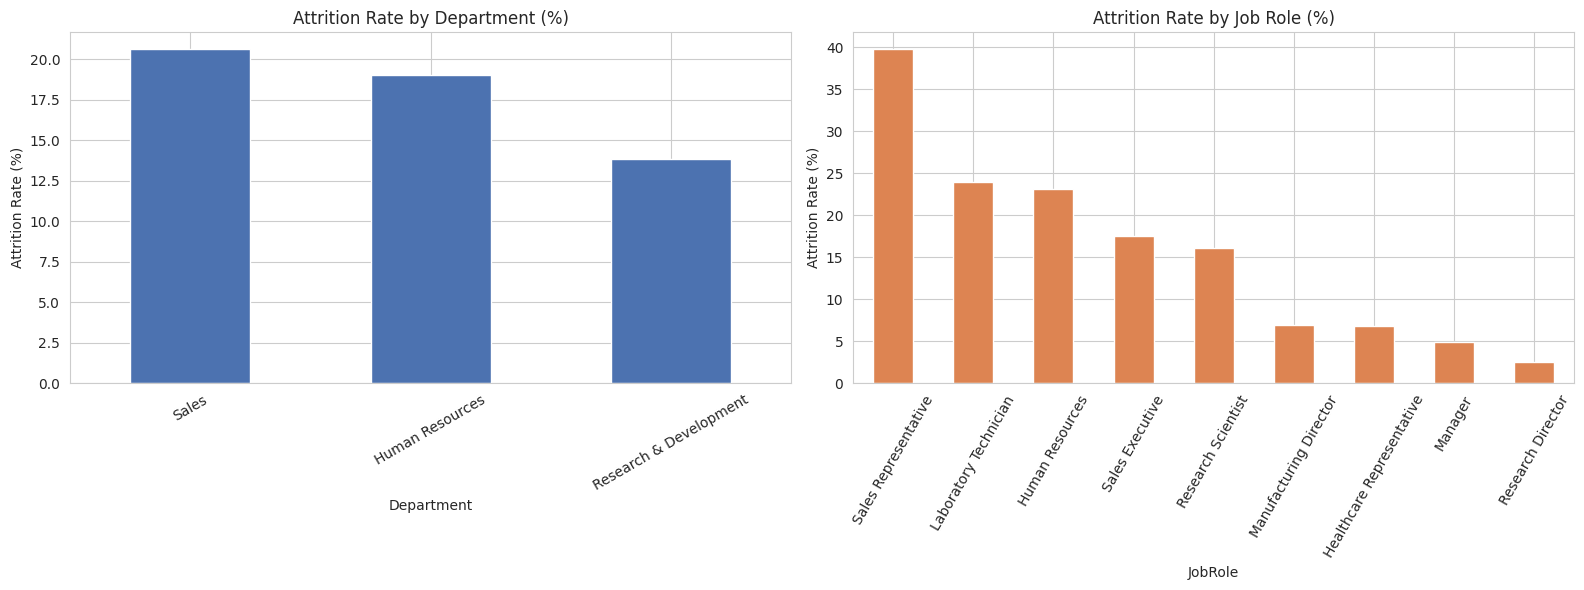

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
dept_attrition.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Attrition Rate by Department (%)')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

role_attrition.plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Attrition Rate by Job Role (%)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.savefig('charts/chart1_attrition_by_dept_role.png', bbox_inches='tight')
plt.show()

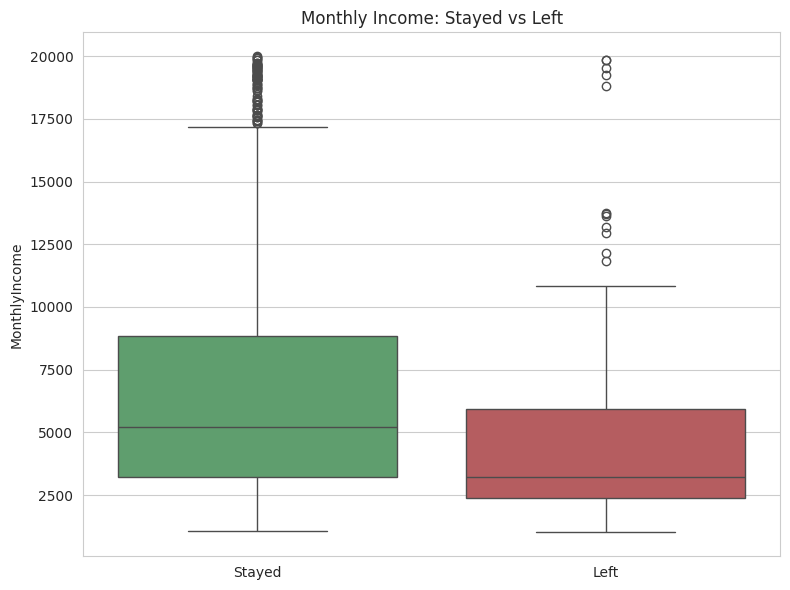

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, hue='Attrition', palette=['#55A868', '#C44E52'], legend=False)
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.title('Monthly Income: Stayed vs Left')
plt.xlabel('')
plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', bbox_inches='tight')
plt.show()

## Task 4 — Model Building & Comparison

Data was already split 80/20 in Task 2. Class imbalance is handled using `class_weight='balanced'` for Logistic Regression and Random Forest. `GradientBoostingClassifier` does not accept `class_weight`, so balanced **sample weights** are passed instead — the same underlying idea (SMOTE is a more advanced alternative worth knowing, but not used here).

In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

sample_weights = compute_sample_weight('balanced', y_train)

results = []
roc_data = {}
fitted_models = {}
predictions = {}

for name, model in models.items():
    if name == 'Gradient Boosting':
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    fitted_models[name] = model
    predictions[name] = (y_pred, y_proba)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({'Model': name, 'Precision': round(precision, 3), 'Recall': round(recall, 3),
                     'F1-Score': round(f1, 3), 'ROC-AUC': round(auc, 3)})

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)

results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.356,0.660,0.463,0.804
1,Random Forest,0.500,0.085,0.145,0.769
2,Gradient Boosting,0.407,0.468,0.436,0.779


## Task 5 — Model Evaluation

In [19]:
print("=== Comparison Table ===")
print(results_df.to_string(index=False))

=== Comparison Table ===
              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.356   0.660     0.463    0.804
      Random Forest      0.500   0.085     0.145    0.769
  Gradient Boosting      0.407   0.468     0.436    0.779


In [20]:
for name in models:
    y_pred, y_proba = predictions[name]
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))
    print()

--- Logistic Regression ---
              precision    recall  f1-score   support

      Stayed       0.92      0.77      0.84       247
        Left       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294


--- Random Forest ---
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294


--- Gradient Boosting ---
              precision    recall  f1-score   support

      Stayed       0.90      0.87      0.88       247
        Left       0.41      0.47      0.44        47

    accuracy                           0.81       294
   macro avg       0.65      0.67      0.66       

In [21]:
best_model_name = results_df.sort_values('ROC-AUC', ascending=False).iloc[0]['Model']
best_model = fitted_models[best_model_name]
y_pred_best, y_proba_best = predictions[best_model_name]
print(f"Best model: {best_model_name}")
print(results_df[results_df['Model'] == best_model_name])

Best model: Logistic Regression
                 Model  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression      0.356    0.66     0.463    0.804


**Why Logistic Regression performed best:** On this dataset, Logistic Regression achieves the highest ROC-AUC (0.804) and by far the best recall (66%) — meaning it catches roughly two-thirds of employees who actually leave, which matters most for an HR retention use case (missing a flight-risk employee is more costly than a false alarm). Random Forest had the highest precision but extremely poor recall (8.5%), making it nearly useless at actually flagging at-risk employees despite looking "accurate" overall. Gradient Boosting sat in between. Because catching true leavers (recall) is the business priority, and Logistic Regression also has the highest ROC-AUC, it is selected as the best model — with the added bonus that it's the most interpretable model for HR stakeholders.

Confusion Matrix (rows=actual, cols=predicted):
[[191  56]
 [ 16  31]]


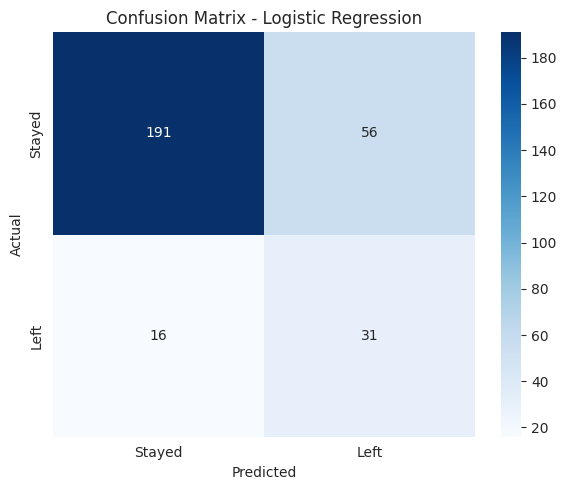

In [22]:
cm = confusion_matrix(y_test, y_pred_best)
print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [23]:
if best_model_name == 'Logistic Regression':
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=False)
else:
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

top10 = importances.head(10)
print("Top 10 most important features driving attrition:")
print(top10)

Top 10 most important features driving attrition:
OverTime_Yes                        1.623568
BusinessTravel_Travel_Frequently    1.598904
JobRole_Laboratory Technician       1.569722
JobRole_Sales Representative        1.276684
JobRole_Research Director           1.117217
EducationField_Other                1.027636
BusinessTravel_Travel_Rarely        0.906933
MaritalStatus_Single                0.864752
JobRole_Human Resources             0.645775
TotalWorkingYears                   0.615535
dtype: float64


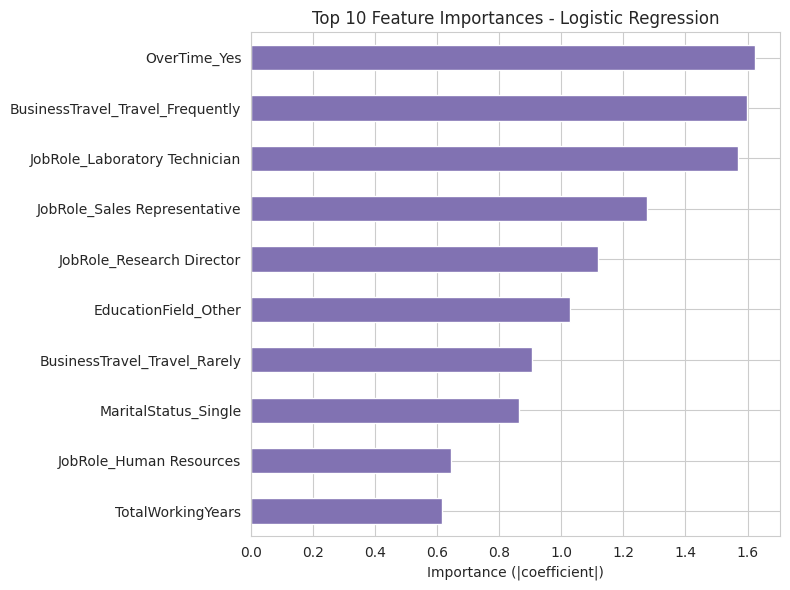

In [24]:
plt.figure(figsize=(8, 6))
top10.sort_values().plot(kind='barh', color='#8172B2')
plt.title(f'Top 10 Feature Importances - {best_model_name}')
plt.xlabel('Importance (|coefficient|)')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', bbox_inches='tight')
plt.show()

## Task 6 — Visualization (Chart 5 bonus: ROC Curve comparison)

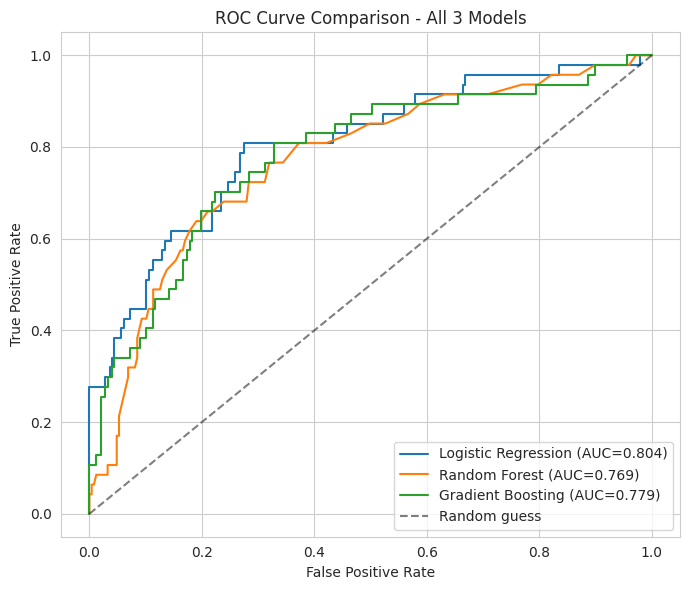

In [25]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All 3 Models')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', bbox_inches='tight')
plt.show()

All 5 charts (Department/Role attrition, Income boxplot, Confusion Matrix, Feature Importance, ROC Curve) are saved as `.png` files inside the `charts/` folder.

## Task 7 — HR Insights & Business Recommendations

**Which 3 factors most strongly predict that an employee will leave?**
The model's top predictors are: (1) **OverTime** — employees who regularly work overtime are far more likely to leave, (2) **Frequent business travel** — employees who travel frequently for work show a much higher exit rate than those who travel rarely or not at all, and (3) **Job role**, specifically Laboratory Technicians and Sales Representatives, who leave at far higher rates than other roles regardless of pay.

**Which department or job role should HR prioritize for retention efforts?**
**Sales Representatives** are the single highest-risk group (39.76% attrition — nearly 4 in 10 leave), followed by Laboratory Technicians (23.94%) and HR staff (23.08%). At the department level, **Sales** (20.63%) and **HR** (19.05%) should be prioritized over R&D (13.84%).

**Does salary alone explain attrition or are there other stronger factors?**
Salary plays a role — leavers earn 30% less on average than those who stay — but it is not the dominant factor. OverTime and travel frequency outrank income in the model's feature importance ranking, meaning **workload and work-life balance issues are driving attrition at least as much as pay**, if not more.

**Two concrete HR recommendations:**
1. Audit and reduce mandatory overtime in the Sales and Lab Technician roles, and review travel policies for frequent travelers — consider travel stipends, schedule flexibility, or rotating travel-heavy assignments to ease the burden.
2. Launch a structured "first 24 months" retention program (mentorship, regular check-ins, faster promotion/role-clarity conversations) since attrition is highest among employees with 0–2 years of tenure and drops sharply after that point.

**Limitation HR should be aware of:**
This model was trained on a relatively small, imbalanced sample (only 237 examples of employees who left) and on historical data from one company snapshot — it can highlight patterns and flag risk, but it should support, not replace, human judgment in retention decisions, and should be retrained periodically as workforce conditions change.
